## We combine both HHL & VQLS


1

In [1]:
# ==========================================
# STEP 0: SETUP & IMPORTS
# ==========================================
import os
import numpy as np
from scipy.linalg import expm
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# Qiskit imports
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import UnitaryGate, QFTGate, RYGate
from qiskit_aer import AerSimulator

PLOTDIR = "plots"
os.makedirs(PLOTDIR, exist_ok=True)

In [2]:
def run_mhd_couette_solver(Ha):
    print(f"\n{'='*50}")
    print(f" MHD Couette Flow Solver | Ha = {Ha}")
    print(f"{'='*50}")

    # ---------------------------------------------------------
    # 1. Classical Setup & Ground Truth
    # ---------------------------------------------------------
    Delta = 1.0 / 3.0
    alpha = 2.0 + Ha**2 * Delta**2

    A = np.array([[alpha, -1.0], [-1.0, alpha]])
    b = np.array([0.0, 1.0])  # |b> = |1>

    x_classical = np.linalg.solve(A, b).real
    eigs = np.sort(np.linalg.eigvalsh(A))

    print("--- Classical Ground Truth ---")
    print(f"Matrix A:\n{A}")
    print(f"Eigenvalues: {eigs}")
    print(f"Classical x: {x_classical}\n")

    # ---------------------------------------------------------
    # 2. VQLS Implementation
    # ---------------------------------------------------------
    print("--- Variational Quantum Linear Solver (VQLS) ---")
    def ansatz(theta):
        qc = QuantumCircuit(1)
        qc.ry(theta[0], 0)
        return qc

    def x_state(theta):
        return Statevector(ansatz(theta)).data

    vqls_history = []  # NEW: track cost per COBYLA iteration for the convergence plot

    def global_cost(theta):
        x = x_state(theta)
        Ax = A @ x
        num = np.abs(np.vdot(b, Ax))**2
        den = (np.vdot(Ax, Ax)).real
        cost = 1 - num/den
        vqls_history.append(cost)  # NEW
        return cost

    # Optimize using COBYLA
    res = minimize(global_cost, [0.1], method='COBYLA', options={'maxiter': 100, 'tol': 1e-11})
    theta_star = res.x[0]

    # Retrieve and rescale direction
    x_q_vqls = x_state([theta_star]).real
    scaling_vqls = np.linalg.norm(x_classical) / np.linalg.norm(x_q_vqls)
    x_q_vqls_scaled = scaling_vqls * x_q_vqls

    # Fix sign ambiguity
    if np.dot(x_q_vqls_scaled, x_classical) < 0:
        x_q_vqls_scaled = -x_q_vqls_scaled

    err_vqls = np.linalg.norm(x_q_vqls_scaled - x_classical)
    print(f"Optimized theta*: {theta_star:.4f}")
    print(f"VQLS x (rescaled): {x_q_vqls_scaled}")
    print(f"VQLS Agreement Error: {err_vqls:.2e}\n")

    # ---------------------------------------------------------
    # 3. HHL Implementation
    # ---------------------------------------------------------
    print("--- HHL Algorithm ---")
    n_clock = 3
    t = np.pi / 4
    C = 1.0
    U = expm(1j * A * t)

    sys = QuantumRegister(1, 's')
    clk = QuantumRegister(n_clock, 'c')
    anc = QuantumRegister(1, 'a')
    qc = QuantumCircuit(anc, clk, sys)

    # Encode |b> = |1>
    qc.x(sys[0])

    # Phase Estimation
    qc.h(clk)
    for i in range(n_clock):
        power = 2**i
        CU_gate = UnitaryGate(np.linalg.matrix_power(U, power)).control(1)
        qc.append(CU_gate, [clk[i], sys[0]])

    # Inverse QFT
    # FIX: QFTGate(num_qubits, inverse=True) is not a valid constructor signature in this
    # Qiskit version. Use QFTGate(n_clock).inverse() instead (same pattern as the original
    # standalone HHL notebook).
    iqft = QFTGate(n_clock).inverse()
    qc.append(iqft, clk)

    # NEW: snapshot the state right after phase estimation (before inversion/uncompute)
    # so we can read off the clock-register (eigenvalue) population for the eigenvalue plot.
    state_after_qpe = Statevector.from_instruction(qc)
    clock_population = np.zeros(2**n_clock)
    for i, amp in enumerate(state_after_qpe.data):
        c_val = (i >> 1) & (2**n_clock - 1)   # anc=bit0, clk=bits1..3, sys=bit4
        clock_population[c_val] += abs(amp)**2

    # Eigenvalue Inversion (Rotation of Ancilla)
    for m in range(1, 2**n_clock):
        theta = 2 * np.arcsin(C / m) if C/m <= 1 else 0
        if theta > 0:
            bin_m = format(m, f'0{n_clock}b')[::-1]

            # Anti-control mapping for zeros
            for idx, bit in enumerate(bin_m):
                if bit == '0':
                    qc.x(clk[idx])

            mcry = RYGate(theta).control(n_clock)
            qc.append(mcry, list(clk) + [anc[0]])

            # Undo Anti-control mapping
            for idx, bit in enumerate(bin_m):
                if bit == '0':
                    qc.x(clk[idx])

    # Uncompute Phase Estimation
    # FIX 1: same QFTGate constructor issue as above.
    # FIX 2: the uncompute must reverse the forward steps in the OPPOSITE order they were
    # applied. Forward order was H -> controlled-U(i=0,1,2) -> inverse-QFT, so uncompute must
    # undo the inverse-QFT FIRST (i.e. apply the forward QFT), THEN undo the controlled-U
    # layers (in reverse, i=2,1,0), THEN undo H last. The original code applied the
    # controlled-U-inverse layers before the QFT, which is backwards and left the clock
    # register in a superposition instead of resetting it to |000>, corrupting the result.
    qft = QFTGate(n_clock)
    qc.append(qft, clk)
    for i in range(n_clock-1, -1, -1):
        power = 2**i
        CU_inv = UnitaryGate(np.linalg.matrix_power(U, power).conj().T).control(1)
        qc.append(CU_inv, [clk[i], sys[0]])
    qc.h(clk)

    # PEEK at statevector to extract the answer (Simulating the measurement filtering)
    state = Statevector.from_instruction(qc)

    # The success state is when ancilla is |1> and clock is |000>.
    # FIX 3: Qiskit statevector indices are little-endian in QUBIT order, and the qubits were
    # added to the circuit as (anc, clk, sys) -> anc is the LOWEST-index (LSB) qubit and sys is
    # the HIGHEST-index (MSB) qubit: index = (sys << 4) | (clk2 << 3) | (clk1 << 2) | (clk0 << 1) | anc.
    # The original code built the index from the string "anc+clk+sys" read MSB-first, which
    # actually placed sys at the MSB and anc at the LSB -- the reverse of the true qubit
    # order -- so it was reading out the wrong amplitudes (system and ancilla swapped).
    idx_0 = (0 << 4) | (0 << 1) | 1  # sys=0, clock=000, ancilla=1
    idx_1 = (1 << 4) | (0 << 1) | 1  # sys=1, clock=000, ancilla=1

    amp_0 = state.data[idx_0]
    amp_1 = state.data[idx_1]

    x_hhl = np.array([amp_0, amp_1])

    # Rescale HHL state to classical solution
    norm_hhl = np.linalg.norm(x_hhl)
    if norm_hhl > 1e-10:
        x_hhl = x_hhl / norm_hhl

    scaling_hhl = np.linalg.norm(x_classical) / np.linalg.norm(x_hhl)
    x_hhl_scaled = scaling_hhl * x_hhl

    if np.dot(x_hhl_scaled.real, x_classical) < 0:
        x_hhl_scaled = -x_hhl_scaled

    err_hhl = np.linalg.norm(x_hhl_scaled.real - x_classical)

    print(f"HHL x (rescaled): {x_hhl_scaled.real}")
    print(f"HHL Agreement Error: {err_hhl:.2e}\n")

    # NEW: package everything needed for plotting
    return dict(
        Ha=Ha, A=A, b=b, eigs=eigs,
        x_classical=x_classical,
        x_q_vqls_scaled=x_q_vqls_scaled, err_vqls=err_vqls, vqls_history=vqls_history,
        x_hhl_scaled=x_hhl_scaled.real, err_hhl=err_hhl,
        n_clock=n_clock, clock_population=clock_population,
    )

In [3]:
# Run and compare algorithms for Ha = 1 and Ha = 3 only
results = {}
results[1.0] = run_mhd_couette_solver(Ha=1.0)
results[3.0] = run_mhd_couette_solver(Ha=3.0)


 MHD Couette Flow Solver | Ha = 1.0
--- Classical Ground Truth ---
Matrix A:
[[ 2.11111111 -1.        ]
 [-1.          2.11111111]]
Eigenvalues: [1.11111111 3.11111111]
Classical x: [0.28928571 0.61071429]

--- Variational Quantum Linear Solver (VQLS) ---
Optimized theta*: -4.0263
VQLS x (rescaled): [0.28928571 0.61071429]
VQLS Agreement Error: 1.54e-10

--- HHL Algorithm ---
HHL x (rescaled): [0.29651207 0.60723863]
HHL Agreement Error: 8.02e-03


 MHD Couette Flow Solver | Ha = 3.0
--- Classical Ground Truth ---
Matrix A:
[[ 3. -1.]
 [-1.  3.]]
Eigenvalues: [2. 4.]
Classical x: [0.125 0.375]

--- Variational Quantum Linear Solver (VQLS) ---
Optimized theta*: 2.4981
VQLS x (rescaled): [0.125 0.375]
VQLS Agreement Error: 1.03e-09

--- HHL Algorithm ---
HHL x (rescaled): [0.125 0.375]
HHL Agreement Error: 3.97e-16



### Plots

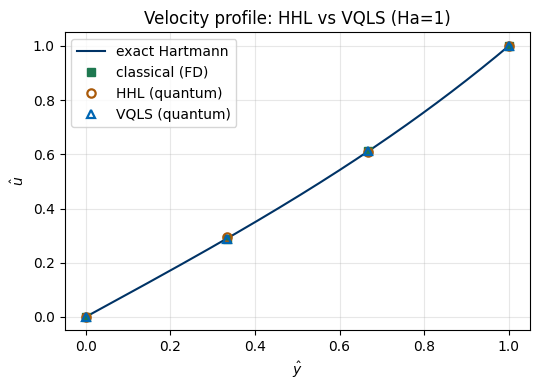

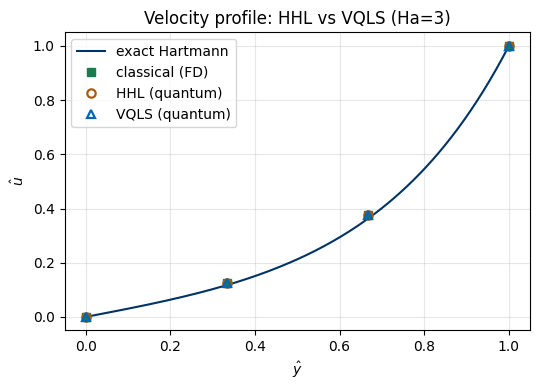

In [4]:
# ==========================================
# VELOCITY PROFILE (classical vs HHL vs VQLS), for Ha = 1 and Ha = 3
# ==========================================
def plot_velocity_profile(res):
    Ha = res["Ha"]
    yf = np.linspace(0, 1, 200)
    uf = np.sinh(Ha * yf) / np.sinh(Ha)          # exact Hartmann profile
    yn = np.array([0, 1/3, 2/3, 1])
    uc = np.array([0, *res["x_classical"], 1])
    uh = np.array([0, *res["x_hhl_scaled"], 1])
    uv = np.array([0, *res["x_q_vqls_scaled"], 1])

    plt.figure(figsize=(5.5, 4))
    plt.plot(yf, uf, "-", color="#003366", label="exact Hartmann")
    plt.plot(yn, uc, "s", color="#1e7850", label="classical (FD)")
    plt.plot(yn, uh, "o", mfc="none", mec="#aa5a0a", mew=1.6, label="HHL (quantum)")
    plt.plot(yn, uv, "^", mfc="none", mec="#0066B3", mew=1.6, label="VQLS (quantum)")
    plt.xlabel(r"$\hat{y}$"); plt.ylabel(r"$\hat{u}$")
    plt.title(f"Velocity profile: HHL vs VQLS (Ha={Ha:.0f})")
    plt.legend(); plt.grid(True, alpha=.3); plt.tight_layout()
    plt.savefig(os.path.join(PLOTDIR, f"velocity_profile_Ha{Ha:.0f}.png"), dpi=150)
    plt.show()

for Ha in [1.0, 3.0]:
    plot_velocity_profile(results[Ha])

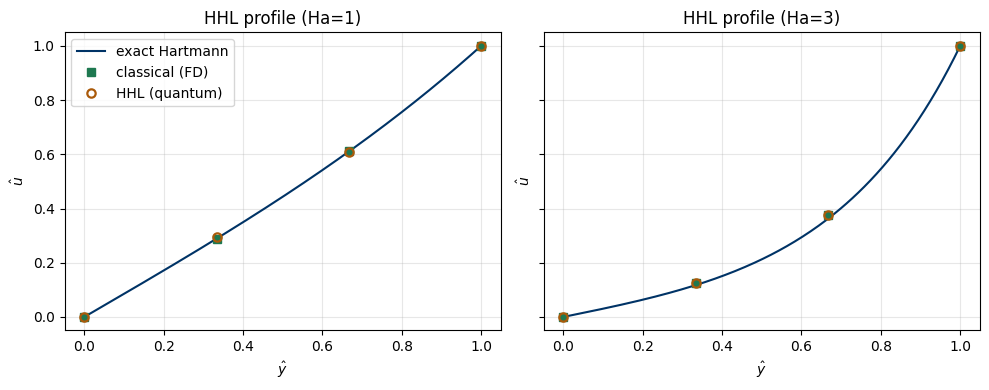

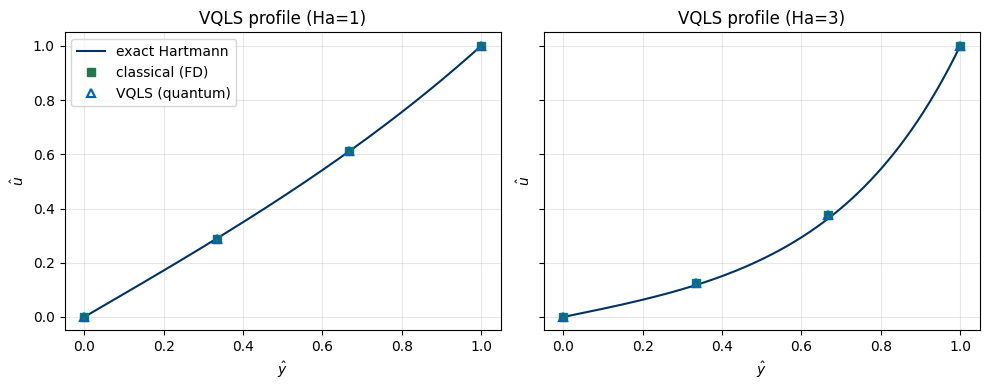

In [5]:
# Add two separate velocity profiles for HHL and VQLS for Ha = 1 and Ha = 3, so we can compare them side by side. Don't plot VQLS and HHL on the same plot, but rather have two separate plots for each Ha value. This will allow for a clearer comparison of the velocity profiles obtained from the classical, HHL, and VQLS methods.
# ==========================================
# SEPARATE VELOCITY PROFILES FOR HHL AND VQLS, FOR Ha = 1 AND Ha = 3
# ==========================================
for solver_name, color, marker in [("HHL", "#aa5a0a", "o"), ("VQLS", "#0066B3", "^")]:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

    for ax, Ha in zip(axes, [1.0, 3.0]):
        res = results[Ha]
        yf = np.linspace(0, 1, 200)
        uf = np.sinh(Ha * yf) / np.sinh(Ha)
        yn = np.array([0, 1/3, 2/3, 1])
        uc = np.array([0, *res["x_classical"], 1])

        if solver_name == "HHL":
            us = np.array([0, *res["x_hhl_scaled"], 1])
        else:
            us = np.array([0, *res["x_q_vqls_scaled"], 1])

        ax.plot(yf, uf, "-", color="#003366", label="exact Hartmann")
        ax.plot(yn, uc, "s", color="#1e7850", label="classical (FD)")
        ax.plot(yn, us, marker, mfc="none", mec=color, mew=1.6, label=f"{solver_name} (quantum)")
        ax.set_xlabel(r"$\hat{y}$")
        ax.set_ylabel(r"$\hat{u}$")
        ax.set_title(f"{solver_name} profile (Ha={Ha:.0f})")
        ax.grid(True, alpha=.3)

    axes[0].legend(loc="best")
    fig.tight_layout()
    fig.savefig(os.path.join(PLOTDIR, f"{solver_name.lower()}_velocity_profiles_Ha1_Ha3.png"), dpi=150)
    plt.show()

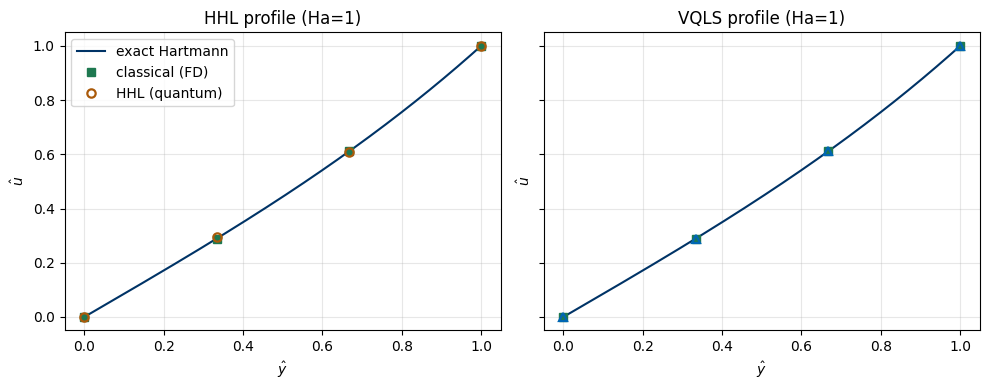

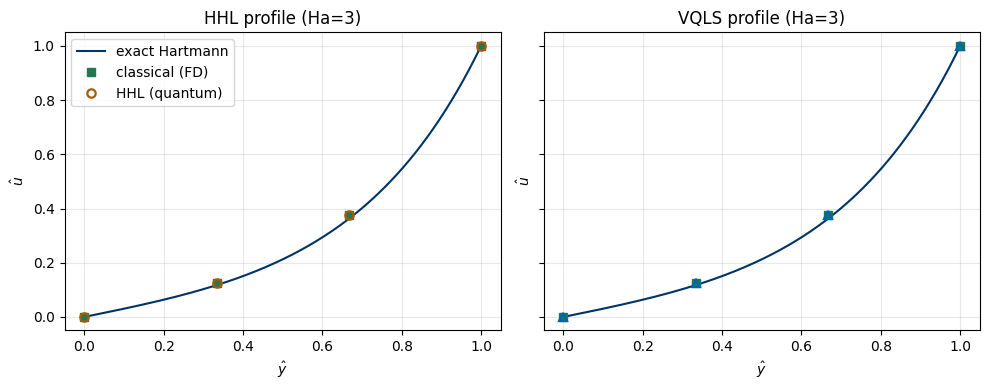

In [8]:
# ==========================================
# HHL VS VQLS COMPARISON FOR EACH Ha VALUE
# ==========================================
for Ha in [1.0, 3.0]:
    res = results[Ha]
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

    for ax, solver_name, color, marker in zip(
        axes,
        ["HHL", "VQLS"],
        ["#aa5a0a", "#0066B3"],
        ["o", "^"],
    ):
        yf = np.linspace(0, 1, 200)
        uf = np.sinh(Ha * yf) / np.sinh(Ha)
        yn = np.array([0, 1/3, 2/3, 1])
        uc = np.array([0, *res["x_classical"], 1])

        if solver_name == "HHL":
            us = np.array([0, *res["x_hhl_scaled"], 1])
        else:
            us = np.array([0, *res["x_q_vqls_scaled"], 1])

        ax.plot(yf, uf, "-", color="#003366", label="exact Hartmann")
        ax.plot(yn, uc, "s", color="#1e7850", label="classical (FD)")
        ax.plot(yn, us, marker, mfc="none", mec=color, mew=1.6, label=f"{solver_name} (quantum)")
        ax.set_xlabel(r"$\hat{y}$")
        ax.set_ylabel(r"$\hat{u}$")
        ax.set_title(f"{solver_name} profile (Ha={Ha:.0f})")
        ax.grid(True, alpha=.3)

    axes[0].legend(loc="best")
    fig.tight_layout()
    fig.savefig(os.path.join(PLOTDIR, f"hhl_vs_vqls_Ha{Ha:.0f}.png"), dpi=150)
    plt.show()

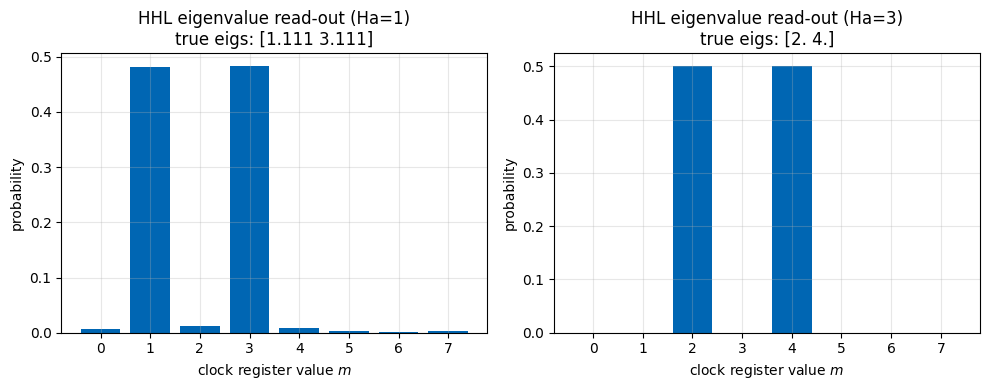

In [6]:
# ==========================================
# HHL EIGENVALUE (CLOCK POPULATION) PLOT, for Ha = 1 and Ha = 3
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, Ha in zip(axes, [1.0, 3.0]):
    res = results[Ha]
    n_clock = res["n_clock"]
    ax.bar(range(2**n_clock), res["clock_population"], color="#0066b3")
    ax.set_xlabel("clock register value $m$")
    ax.set_ylabel("probability")
    ax.set_title(f"HHL eigenvalue read-out (Ha={Ha:.0f})\ntrue eigs: {np.round(res['eigs'], 3)}")
    ax.grid(True, alpha=.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTDIR, "hhl_eigenvalue_populations_Ha1_Ha3.png"), dpi=150)
plt.show()

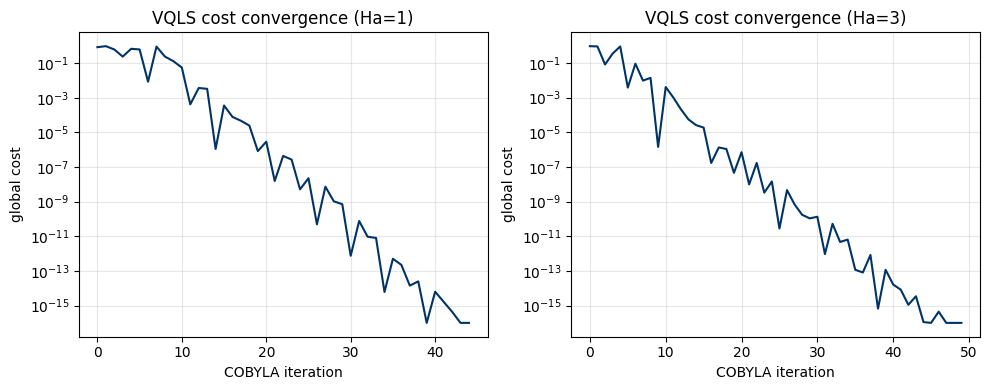

In [7]:
# ==========================================
# VQLS COST FUNCTION CONVERGENCE PLOT, for Ha = 1 and Ha = 3
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, Ha in zip(axes, [1.0, 3.0]):
    res = results[Ha]
    ax.semilogy(np.maximum(res["vqls_history"], 1e-16), color="#003366")
    ax.set_xlabel("COBYLA iteration"); ax.set_ylabel("global cost")
    ax.set_title(f"VQLS cost convergence (Ha={Ha:.0f})")
    ax.grid(True, alpha=.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTDIR, "vqls_cost_convergence_Ha1_Ha3.png"), dpi=150)
plt.show()